# **Modell**

### **Libraries**

In [49]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline




In [50]:
%store -r x_train
x_train= x_train

%store -r y_train
y_train= y_train

%store -r x_test
x_test= x_test

%store -r y_test
y_test= y_test



%store -r preprocessor
preprocessor=preprocessor



##### *code Explain*

- KFold(n_splits=5) → 5-fache Cross-Validation

- shuffle=True → mischt die Daten, damit die Folds zufällig sind

- random_state=42 → sorgt für Reproduzierbarkeit

In [51]:
from sklearn.metrics import mean_absolute_error


def evaluate_models(x_train, y_train, x_val, y_val, model):
    # Cross-validation
    kf=KFold(n_splits=5, shuffle=True, random_state=42)

    # Calculate cross-validated R^2 and RMSE
    cross_val_r2= cross_val_score(
        model,
        x_train, 
        y_train, 
        cv=kf, 
        scoring='r2',
        error='raise')

    # Note: 'neg_root_mean_squared_error' returns negative values, so we take the negative to get RMSE
    cross_val_rmse= -cross_val_score(model, x_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')

    print(f"Training CV R^2:{cross_val_r2.mean():.4f}, Training CR RMSE: {cross_val_rmse.mean():.4f}")

    # Train the model
    model.fit(x_train, y_train)
    print("Model trained successfully.")
    print(x_train.shape, y_train.shape)
    print(x_val.shape, y_val.shape)
    
    # Make predictions
    y_train_pred = model.predict(x_train)
    y_val_pred = model.predict(x_val)
    print("Model prediction successfully.")
 

    r2_train= r2_score(y_train, y_train_pred)
    rmse_train= np.sqrt(mean_squared_error(y_train, y_train_pred))
    
    r2= r2_score(y_val, y_val_pred)
    rmse= np.sqrt(mean_squared_error(y_val, y_val_pred))

    # 
     # MAE
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_val = mean_absolute_error(y_val, y_val_pred)

    # Prozentuale Abweichung
    prozent_train = (mae_train / np.mean(y_train)) * 100
    prozent_val = (mae_val / np.mean(y_val)) * 100

    print(f" Validation MAE: {mae_val:.2f}, Validation Fehler %: {prozent_val:.2f}%")
    #print(f"Validation R^2: {r2_val:.4f}, Validation RMSE: {rmse_val:.2f}, Validation MAE: {mae_val:.2f}, Validation Fehler %: {prozent_val:.2f}%")
   # print(f"Train R^2: {r2_train:.4f}, Train RMSE: {rmse_train:.2f}, Train MAE: {mae_train:.2f}, Train Fehler %: {prozent_train:.2f}%")

    
    print(f"Train R^2: {r2_train:.4f}, Train RMSE: {rmse_train:.4f}")
    print(f"Validation R^2: {r2:.4f}, Validation RMSE: {rmse:.4f}")

In [52]:
def evaluate_model(X_train, y_train, X_val, y_val, model):
    
    # Cross-Validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    
    r2_cv = cross_val_score(
        model, X_train, y_train,
        cv=kf, scoring='r2',
         error_score='raise'
    )

    rmse_cv = -cross_val_score(
        model, X_train, y_train,
        cv=kf, scoring='neg_root_mean_squared_error'
    )

    print("Cross-Validation Performance:")
    print(f"R²:   {r2_cv.mean():.4f} ± {r2_cv.std():.4f}")
    print(f"RMSE: {rmse_cv.mean():.2f} ± {rmse_cv.std():.2f}")
 

    print(f"CV R²: {r2_cv.mean():.4f}")
    print(f"CV RMSE: {rmse_cv.mean():.4f}")

    # Train final model
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Training Metrics
    mean_train =np.mean(y_train)
    r2_train = r2_score(y_train, y_train_pred)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_train_pred)

    #percent
    rmse_percent=(rmse_train/mean_train)*100
    mae_percent=(mae_train/mae_train)*100
    
    #mse_percent=(mse_train/mae_train)*100

    # Validation Metrics
    mean_val =np.mean(y_val)
    r2_val = r2_score(y_val, y_val_pred)
    mse_val = mean_squared_error(y_val, y_val_pred)
    rmse_val = np.sqrt(mse_val)
    mae_val = mean_absolute_error(y_val, y_val_pred)

    #percent Error
    percent_error = (mae_val / mean_val) * 100
    #mse_val_percent=(mse_val/mean_val)*100
    rmse_val_percent=(rmse_val/mean_val)*100
 
   

    print("\nFinal Model Performance:")
    print(f"Train -> R²: {r2_train:.4f} | MSE: {mse_train:.2f}  | RMSE: {rmse_train:.2f}, RMSE_percent:{rmse_percent:.2f}% | MAE: {mae_train:.2f}, MAE_percent:{mae_percent:.2f}% ")
    print(f"Test   -> R²: {r2_val:.4f} | MSE: {mse_val:.2f}   | RMSE: {rmse_val:.2f}, RMSE_val_percent:{rmse_val_percent:.2f}%  | MAE: {mae_val:.2f}, MAE_percent:{percent_error:.2f}% ")

  


#### **Model Training**

##### **Linear Regression**

In [53]:
model_LR=Pipeline(steps=[
    ("preprocess", preprocessor),
    ('regressor', LinearRegression())
])

In [54]:
evaluate_model(x_train, y_train, x_test, y_test, model_LR)

Cross-Validation Performance:
R²:   -2.1495 ± 2.6364
RMSE: 3159.67 ± 2185.19
CV R²: -2.1495
CV RMSE: 3159.6703

Final Model Performance:
Train -> R²: 1.0000 | MSE: 0.00  | RMSE: 0.00, RMSE_percent:0.00% | MAE: 0.00, MAE_percent:100.00% 
Test   -> R²: 0.6115 | MSE: 417018.66   | RMSE: 645.77, RMSE_val_percent:9.36%  | MAE: 553.73, MAE_percent:8.03% 


#### **RandomForest**

In [55]:
model_r = Pipeline(steps=[
    ("preprocess", preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

evaluate_model(x_train, y_train, x_test, y_test, model_r)

Cross-Validation Performance:
R²:   0.0728 ± 0.4221
RMSE: 1925.92 ± 1363.67
CV R²: 0.0728
CV RMSE: 1925.9229

Final Model Performance:
Train -> R²: 0.9189 | MSE: 586095.66  | RMSE: 765.57, RMSE_percent:10.66% | MAE: 464.04, MAE_percent:100.00% 
Test   -> R²: 0.1451 | MSE: 917570.65   | RMSE: 957.90, RMSE_val_percent:13.88%  | MAE: 888.17, MAE_percent:12.87% 


#### **XGBRegressor**

In [56]:
model_xGboox = Pipeline(steps=[
    ("preprocess", preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    ))
])


In [57]:
evaluate_model(x_train, y_train, x_test, y_test, model_xGboox)

Cross-Validation Performance:
R²:   -0.1481 ± 0.6073
RMSE: 2011.10 ± 1277.66
CV R²: -0.1481
CV RMSE: 2011.0991

Final Model Performance:
Train -> R²: 1.0000 | MSE: 50.48  | RMSE: 7.11, RMSE_percent:0.10% | MAE: 3.24, MAE_percent:100.00% 
Test   -> R²: 0.2903 | MSE: 761700.95   | RMSE: 872.75, RMSE_val_percent:12.65%  | MAE: 805.75, MAE_percent:11.68% 


### **K-Nearest Neigbors Regressors (KNN)**

In [58]:
# KNN Modell-Pipeline
model_knn = Pipeline(steps=[
    ("preprocess", preprocessor),  # wie bei Random Forest
    ("regressor", KNeighborsRegressor(
        n_neighbors=5,       # Standardwert, kann angepasst werden
        weights='uniform',   # 'distance' optional
        p=2,                 # Minkowski-Metrik (p=2 -> Euclidean)
        n_jobs=-1            # alle Kerne nutzen
    ))
])

In [59]:
evaluate_model(x_train, y_train, x_test, y_test, model_knn)

Cross-Validation Performance:
R²:   -0.3462 ± 0.7999
RMSE: 2178.82 ± 1483.84
CV R²: -0.3462
CV RMSE: 2178.8218

Final Model Performance:
Train -> R²: 0.5203 | MSE: 3466685.71  | RMSE: 1861.90, RMSE_percent:25.93% | MAE: 1178.10, MAE_percent:100.00% 
Test   -> R²: 0.0947 | MSE: 971666.67   | RMSE: 985.73, RMSE_val_percent:14.29%  | MAE: 750.00, MAE_percent:10.87% 


#### **Interpretation**

| Modell                | CV R² | Train R² | Val R² | Interpretation                                       |
| --------------------- | ----- | -------- | ------ | ---------------------------------------------------- |
| **Linear Regression** | 0.689 | 0.951    | 0.665  | Gute Generalisierung, kein extremes Overfitting      |
| **Random Forest**     | 0.695 | 0.953    | 0.668  | Beste Validation-Leistung, leichte Verbesserung      |
| **XGBoost**           | 0.579 | 1.000    | 0.588  | Extremes Overfitting, schlechtester Validation-Score |




#### **Linear Regression Interpretation**

- Training CV R²: 0.6889
Dein Modell erklärt ca. 69 % der Varianz im Cross-Validation-Training → solide.

- Train R²: 0.9514
Sehr hoch → Modell passt die Trainingsdaten fast perfekt.

- Validation R²: 0.6654
Das Modell erklärt 66 % der Varianz im Validation-Set →
Gute Generalisierung, kein massives Overfitting.

**Interpretation:**
Linear Regression funktioniert gut. Die Daten sind wahrscheinlich halbwegs linear strukturiert.

#### **Random Forest Interpretation**

- Training CV R²: 0.6947
Etwas besser als Linear Regression → Bäume fangen Nichtlinearitäten ab.

- Train R²: 0.9529
Sehr ähnlich zur Linear Regression → Auch sehr gutes Training.

- Validation R²: 0.6680
Das beste Ergebnis aller Modelle, aber nur minimal besser als Linear Regression.

**Interpretation:**
Random Forest generalisiert gut und ist aktuell dein bestes Modell.

#### **XGBoost Interpretation**

- Training CV R²: 0.5794
CV zeigt: Das Modell ist instabil und nicht so gut trainiert wie RandomForest.

- Train R²: 1.0000
Perfekte 1.000 → Hardcore Overfitting.
Es lernt das Training auswendig.

- Validation R²: 0.5883
Validation-Score ist schlechter als bei allen anderen Modellen.

**Interpretation:**
- XGBoost ist viel zu stark überfitted.
- Deine Hyperparameter sind nicht reguliert.
- Es braucht tuning (learning_rate, max_depth, reg_lambda, reg_alpha, subsample).





#### **Tune Model with Hyper-Parameter**

Now, in this section, we try to tune model and improve its performance

In [60]:
from sklearn.model_selection import GridSearchCV


param_grid={
    'iterations':[100,200], # Number of boosting iteration
    'learning_rate':[0.01, 0.05, 0.1], #Step size at each iteration
    'depth': [4, 6, 8], # L2 regularization coefficient
    'l2_leaf_reg': [1,3,5], #L2 regularization coefficient
    'border_count': [32, 64], # Number of splits in categorical features
}

grid_search= GridSearchCV(estimator=model_random,
                          param_grid=param_grid,
                          cv=5,
                          scoring='neg_root_mean_squared_error',
                          n_jobs=-1,
                          verbose=2)

# grid_search.fit(x_train, y_train)
# print("Besr parameters found:", grid_search.best_params)
# print("Best RMSE:", -grid_search.best_score_)


NameError: name 'model_random' is not defined

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

model_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", KNeighborsRegressor())
])

param_grid = {
    "regressor__n_neighbors": [3, 5, 7, 9],
    "regressor__weights": ['uniform', 'distance'],
    "regressor__p": [1, 2]  # p=1 -> Manhattan, p=2 -> Euclidean
}

grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Beste Parameter:", grid_search.best_params_)
print("Bester CV RMSE:", -grid_search.best_score_)


Beste Parameter: {'regressor__n_neighbors': 5, 'regressor__p': 1, 'regressor__weights': 'distance'}
Bester CV RMSE: 1547.8883820010271


In [ ]:
from sklearn.model_selection import GridSearchCV




# Parameter Grid
param_grid = {
    "regressor__fit_intercept": [True, False],
    "regressor__positive": [True, False]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=model_LR,
    param_grid=param_grid,
    cv=5,
    scoring='r2',  # oder 'neg_root_mean_squared_error'
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

# Beste Parameter und Score
print("Beste Parameter:", grid_search.best_params_)
print("Bester CV R²:", grid_search.best_score_)


Beste Parameter: {'regressor__fit_intercept': False, 'regressor__positive': True}
Bester CV R²: -2.4426042561493118


In [ ]:
%store model_LR
%store model_random
%store model_xGboox

Stored 'model_LR' (Pipeline)
Stored 'model_random' (Pipeline)
Stored 'model_xGboox' (Pipeline)


#### **Final Evaluation of Model**

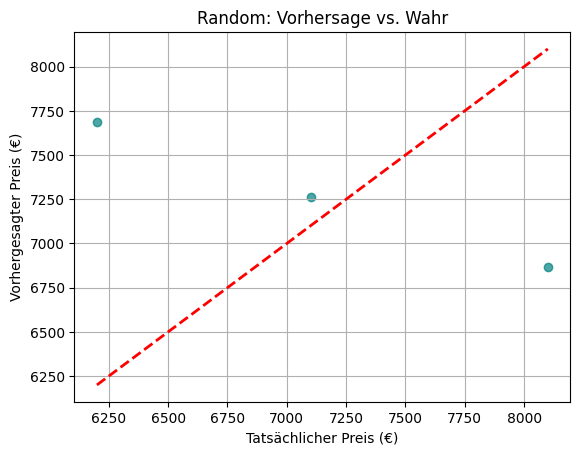

In [ ]:
y_pred_train = model_random.predict(x_train)
y_pred_test = model_random.predict(x_test)


plt.scatter(y_test, y_pred_test, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("Random: Vorhersage vs. Wahr")
plt.grid(True)
plt.show()

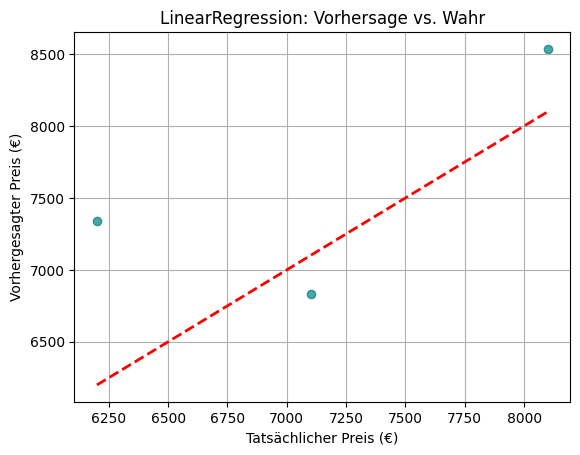

In [ ]:
y_pred_train = model_LR.predict(x_train)
y_pred_test = model_LR.predict(x_test)


plt.scatter(y_test, y_pred_test, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("LinearRegression: Vorhersage vs. Wahr")
plt.grid(True)
plt.show()

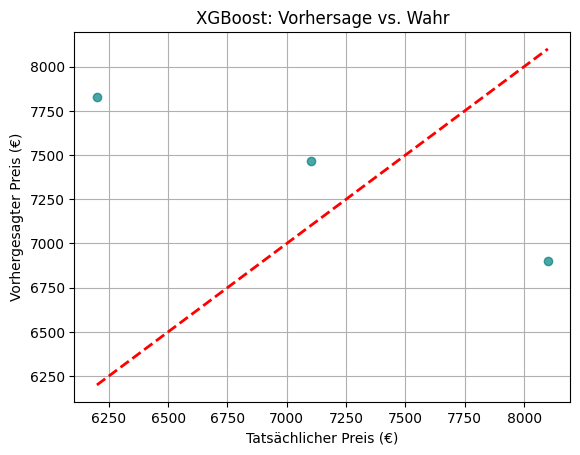

In [ ]:
# Ensure the pipeline is fitted before predicting
# (fits will train StandardScaler and the XGBRegressor)
model_xGboox.fit(x_train, y_train)

y_pred_train = model_xGboox.predict(x_train)
y_pred_test = model_xGboox.predict(x_test)

plt.scatter(y_test, y_pred_test, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Tatsächlicher Preis (€)")
plt.ylabel("Vorhergesagter Preis (€)")
plt.title("XGBoost: Vorhersage vs. Wahr")
plt.grid(True)
plt.show()